<div style="font-family: Palatino Linotype, Palatino, serif; border-bottom: 3px solid #B85300; padding-bottom: 14px; margin-bottom: 6px;">
<h1 style="color: #B85300; margin-bottom: 4px; letter-spacing: 0.5px;">Analisis de Clustering &mdash; Mall Customer Segmentation</h1>
<p style="color: #3B2412; font-size: 15px; margin-top: 0;">Dataset de negocio / comportamiento de clientes &mdash; K-Means y Clustering Jerarquico Aglomerativo</p>
<p style="color: #3B2412; font-size: 13px; opacity: 0.75; margin-top: 2px;">Mineria de Datos / Dataset 1</p>
</div>

<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">1. Configuracion Inicial</h2>
</div>

In [1]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts import preprocessing, clustering, visualization, style

style.set_plot_style()

NOMBRE_DATASET = "Mall Customer Segmentation"


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">2. Seleccion y Carga de Datos</h2>
</div>

In [2]:
DATA_PATH = "../data/dataset1_mall/Mall_Customers.csv"

df = preprocessing.load_data(DATA_PATH)
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
preprocessing.explore_data(df)


Dimensiones: 200 filas x 5 columnas

Tipos de datos:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object 

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64 

Estadisticas descriptivas:
                        count unique     top freq   mean        std   min  \
CustomerID              200.0    NaN     NaN  NaN  100.5  57.879185   1.0   
Gender                    200      2  Female  112    NaN        NaN   NaN   
Age                     200.0    NaN     NaN  NaN  38.85  13.969007  18.0   
Annual Income (k$)      200.0    NaN     NaN  NaN  60.56  26.264721  15.0   
Spending Score (1-100)  200.0    NaN     NaN  NaN   50.2  25.823522   1.0   

                          25%    50%     75%    max  
CustomerID              50.75  100.5  150.25 

<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">3. Preprocesamiento de Datos</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.1 Manejo de valores nulos / atipicos</h3>

In [4]:
# Mall Customers no suele traer nulos, pero validamos igual
if df.isnull().sum().sum() > 0:
    df_limpio = preprocessing.handle_missing_values(df, strategy="drop")
else:
    df_limpio = df.copy()

# Revision de outliers en las variables numericas clave
df_limpio = preprocessing.handle_outliers(
    df_limpio, columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print(f"Filas originales: {len(df)} -> Filas despues de limpieza: {len(df_limpio)}")


'Annual Income (k$)': 2 filas eliminadas por outliers (IQR)
Filas originales: 200 -> Filas despues de limpieza: 198


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.2 Seleccion de variables numericas</h3>

In [5]:
# TODO: definir la lista de columnas numericas relevantes para el clustering
COLUMNAS_NUMERICAS = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = preprocessing.select_numeric_features(df_limpio, COLUMNAS_NUMERICAS)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.3 Normalizacion / Estandarizacion</h3>

<div style="font-family: Palatino Linotype, Palatino, serif; background-color: #FDE8E8; border-left: 4px solid #B83A3A; padding: 10px 16px; margin: 12px 0; border-radius: 3px;">
<p style="color: #3B2412; margin: 0; font-size: 14px;">&#9888; Obligatorio segun el enunciado: sin este paso, variables con escalas distintas sesgan el calculo de distancias.</p>
</div>

In [6]:
X_scaled, scaler = preprocessing.scale_features(X, method="standard")


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">4. Determinacion del Numero Optimo de Clusters (K)</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">Metodo del Codo de Jambu</h3>

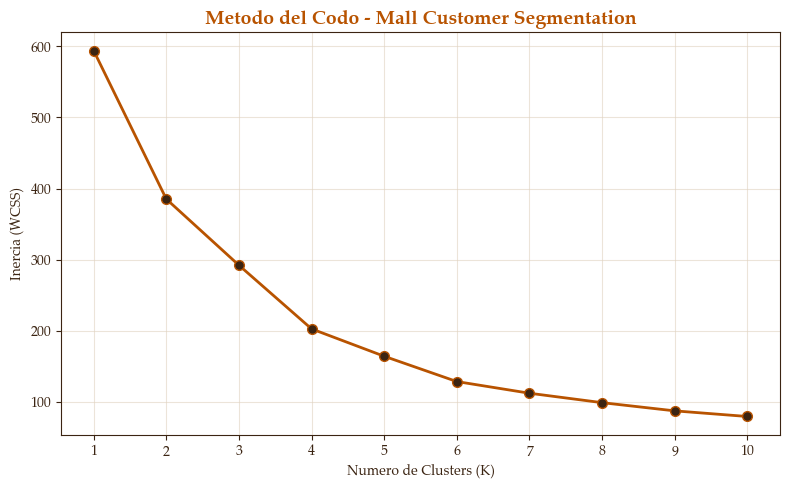

In [7]:
K_RANGE = range(1, 11)
inertias = clustering.elbow_method(X_scaled, k_range=K_RANGE)

visualization.plot_elbow(inertias, K_RANGE, title=f"Metodo del Codo - {NOMBRE_DATASET}")


In [ ]:
K_OPTIMO = 5  


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">5. Aplicacion de Algoritmos</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">5.1 K-Means</h3>

In [9]:
labels_kmeans, modelo_kmeans = clustering.kmeans_clustering(X_scaled, n_clusters=K_OPTIMO)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">5.2 Clustering Jerarquico Aglomerativo</h3>

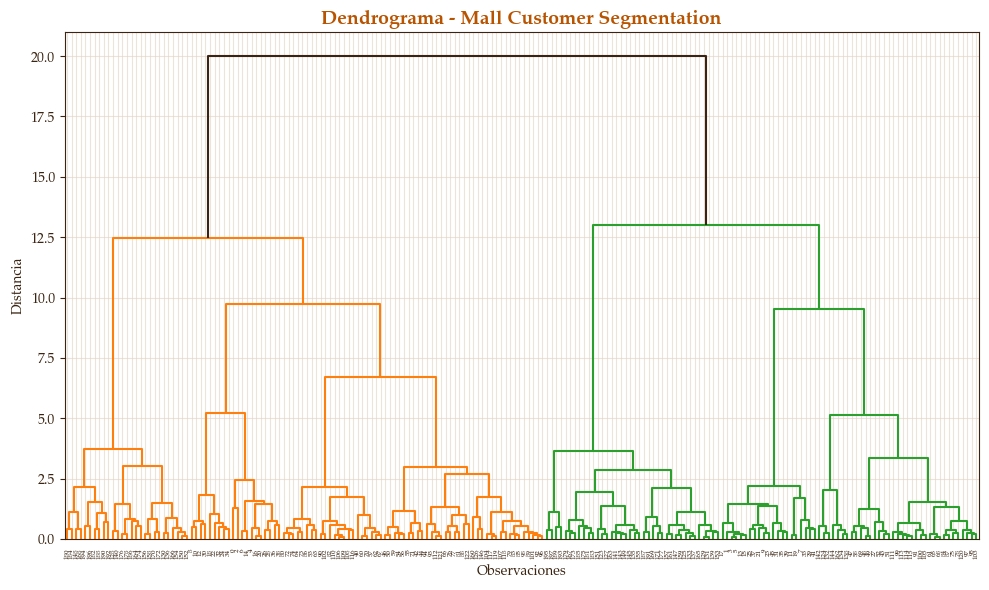

In [10]:
LINKAGE_METODO = "ward"  # Ward minimiza la varianza intra-cluster; funciona bien con variables escaladas

labels_jerarquico = clustering.hierarchical_clustering(X_scaled, n_clusters=K_OPTIMO, linkage=LINKAGE_METODO)

Z = clustering.linkage_matrix(X_scaled, method=LINKAGE_METODO)
visualization.plot_dendrogram(Z, title=f"Dendrograma - {NOMBRE_DATASET}")


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">6. Analisis y Conclusiones Visuales</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.1 Reduccion de dimensionalidad (PCA)</h3>

In [11]:
X_pca, varianza_explicada = clustering.apply_pca(X_scaled, n_components=2)
print("Varianza explicada por componente:", varianza_explicada)


Varianza explicada por componente: [0.44315646 0.33342311]


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.2 Visualizacion de clusters</h3>

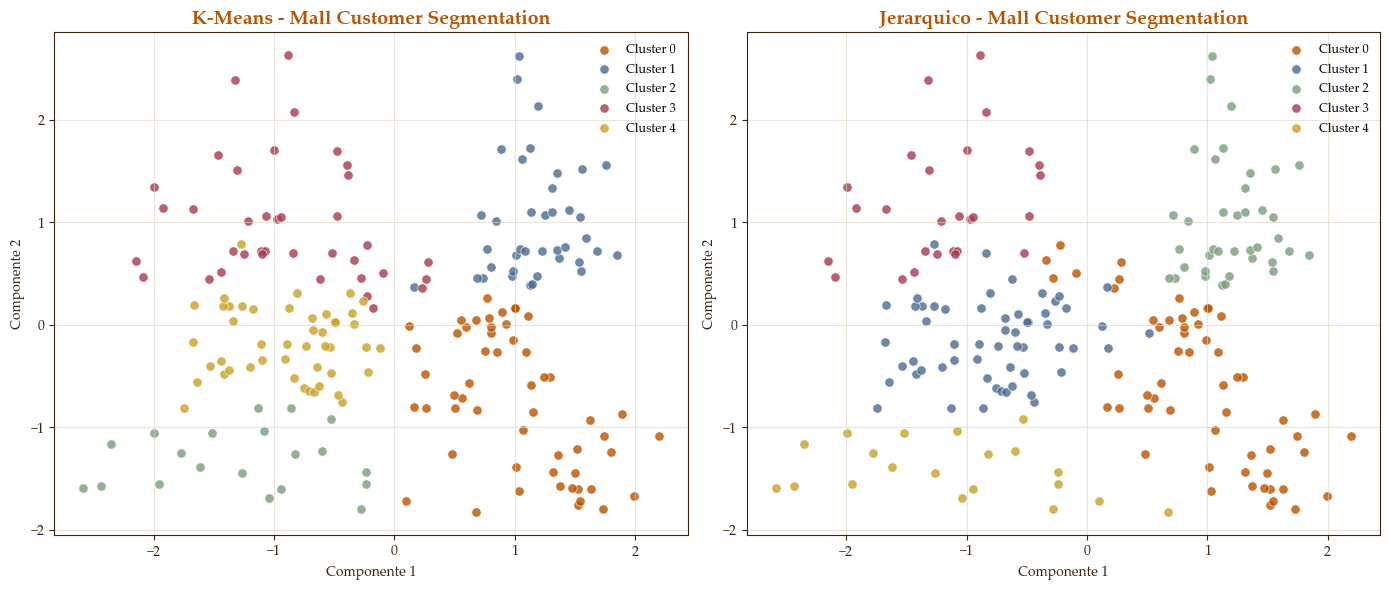

In [12]:
visualization.plot_comparison(X_pca, labels_kmeans, labels_jerarquico, dataset_name=NOMBRE_DATASET)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.3 Interpretacion de los clusters</h3>

<div style="font-family: Palatino Linotype, Palatino, serif; color: #020100; font-size: 14px; line-height: 1.6;">
<p><strong>Cluster 0 (Ahorradores cautelosos, n=20):</strong> Edad promedio 46 años, ingreso bajo (26.8k) y spending score bajo (18.4). Clientes con poco poder adquisitivo y poco interés de compra; segmento de menor prioridad comercial.</p>
<p><strong>Cluster 1 (Jóvenes gastadores moderados, n=54):</strong> Edad promedio 25 años, ingreso medio-bajo (41.1k) pero spending score alto (62.2). Es el cluster más grande; consumidores jóvenes dispuestos a gastar pese a no tener ingresos altos.</p>
<p><strong>Cluster 2 (Target ideal, n=40):</strong> Edad promedio 33 años, ingreso alto (86.1k) y spending score alto (81.5). El segmento más rentable: alto poder adquisitivo combinado con alta disposición de gasto. Prioridad de retención.</p>
<p><strong>Cluster 3 (Alto ingreso, gasto bajo, n=39):</strong> Edad promedio 40 años, ingreso alto (86.1k) pero spending score bajo (19.4). Mismo nivel de ingreso que el Cluster 2, pero comportamiento de gasto opuesto — sugiere que el ingreso por sí solo no explica el gasto; hay una oportunidad de marketing para entender por qué este grupo no consume pese a poder hacerlo.</p>
<p><strong>Cluster 4 (Adultos, comportamiento promedio, n=47):</strong> Edad promedio 56 años, ingreso medio (54.4k) y spending score medio (48.9). Segmento sin comportamientos extremos, representa al cliente "típico" del centro comercial.</p>
</div>